# TUGAS A — Notebook Pertama Machine Learning

**Nama:** Cornelius Steven Tanuwijaya  
**NIM:** 2553110005

**Mata Kuliah:** Pembelajaran mesin dan kecerdasan buatan

Notebook ini dibuat untuk memenuhi Tugas Mandiri Pertemuan 1 mata kuliah Machine Learning & AI.

## Pendahuluan

Pada tugas ini saya akan menerapkan konsep dasar Machine Learning menggunakan dua dataset bawaan dari scikit-learn, yaitu dataset Iris dan Wine.

Tahapan yang dilakukan adalah memahami dataset, membuat visualisasi data, melakukan train/test split, melatih model Machine Learning, dan mengevaluasi hasil menggunakan classification report.

# BAGIAN 1 — DATASET IRIS

Dataset Iris adalah dataset yang digunakan untuk mengklasifikasikan spesies bunga berdasarkan beberapa ukuran bagian bunga.

## T / E / P Dataset Iris

### T (Task / Tugas)
Tugas dari model adalah menebak spesies bunga Iris berdasarkan ukuran sepal dan petal.

### E (Experience / Pengalaman)
Model belajar dari 150 data bunga Iris yang sudah memiliki informasi ukuran dan label spesies.

### P (Performance / Penilaian)
Hasil model dinilai menggunakan akurasi dan classification report pada data test yang sebelumnya belum pernah digunakan untuk melatih model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("Library berhasil diimport!")

Library berhasil diimport!


In [ ]:
iris = load_iris(as_frame=True)

df_iris = iris.frame.copy()

df_iris["species"] = df_iris["target"].map(
    dict(enumerate(iris.target_names))
)

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
print("Ukuran dataset:", df_iris.shape)

print("\nInformasi data:")
df_iris.info()

print("\nStatistik deskriptif:")
display(df_iris.describe())

Ukuran dataset: (150, 6)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistik deskriptif:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Visualisasi Dataset Iris

Berikut adalah beberapa visualisasi untuk membantu memahami karakteristik dan pola pada dataset Iris.

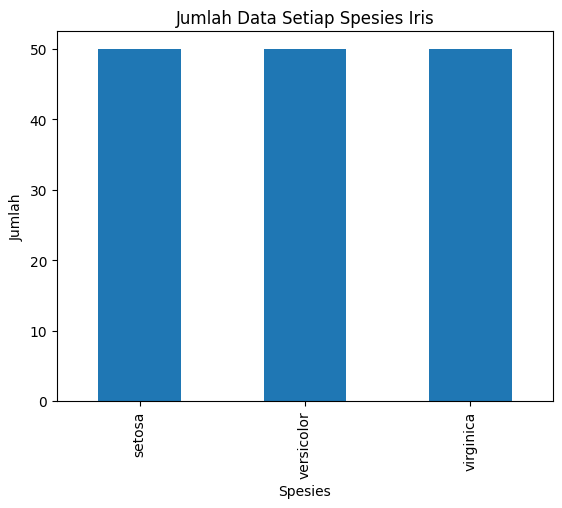

In [ ]:
df_iris["species"].value_counts().plot(kind="bar")

plt.title("Jumlah Data Setiap Spesies Iris")
plt.xlabel("Spesies")
plt.ylabel("Jumlah")

plt.show()

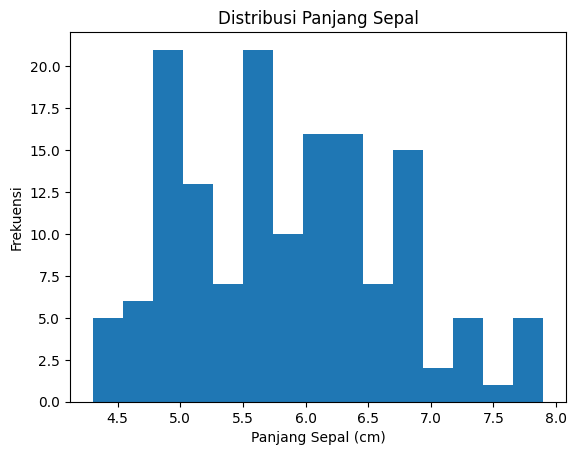

In [ ]:
plt.hist(df_iris["sepal length (cm)"], bins=15)

plt.title("Distribusi Panjang Sepal")
plt.xlabel("Panjang Sepal (cm)")
plt.ylabel("Frekuensi")

plt.show()

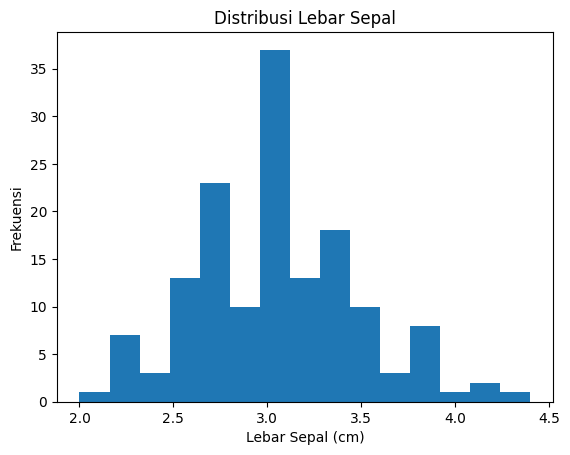

In [ ]:
plt.hist(df_iris["sepal width (cm)"], bins=15)

plt.title("Distribusi Lebar Sepal")
plt.xlabel("Lebar Sepal (cm)")
plt.ylabel("Frekuensi")

plt.show()

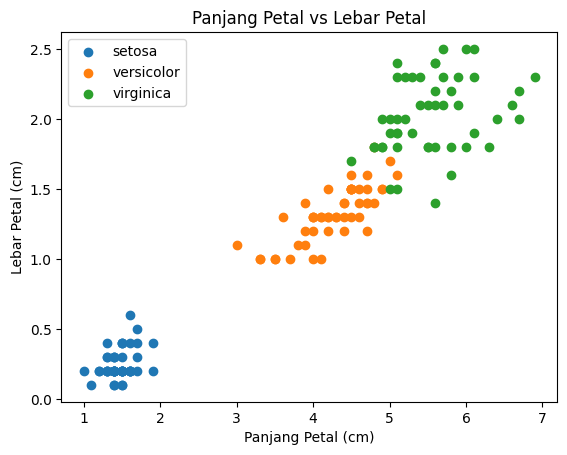

In [ ]:
for species in iris.target_names:
    data = df_iris[df_iris["species"] == species]

    plt.scatter(
        data["petal length (cm)"],
        data["petal width (cm)"],
        label=species
    )

plt.title("Panjang Petal vs Lebar Petal")
plt.xlabel("Panjang Petal (cm)")
plt.ylabel("Lebar Petal (cm)")

plt.legend()

plt.show()

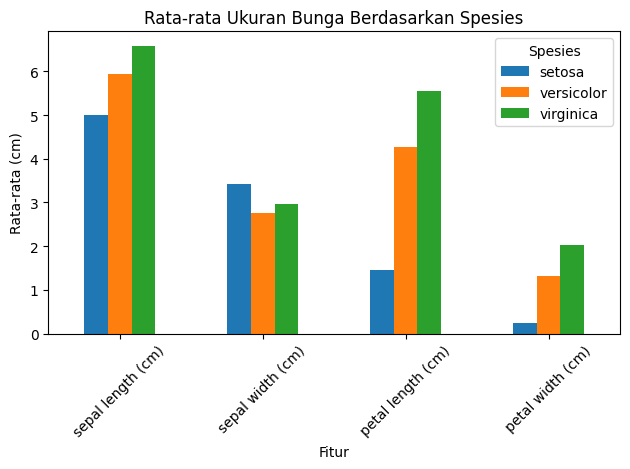

In [ ]:
mean_features = df_iris.groupby("species")[iris.feature_names].mean()

mean_features.T.plot(kind="bar")

plt.title("Rata-rata Ukuran Bunga Berdasarkan Spesies")
plt.xlabel("Fitur")
plt.ylabel("Rata-rata (cm)")

plt.xticks(rotation=45)

plt.legend(title="Spesies")

plt.tight_layout()

plt.show()

## Train/Test Split dan Machine Learning Model

Dataset akan dibagi menjadi dua bagian, yaitu data training dan data testing.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji kemampuan model dalam memprediksi data baru.

In [ ]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 105
Jumlah data testing: 45


In [ ]:
model_iris = LogisticRegression(max_iter=1000)

model_iris.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


In [ ]:
y_pred = model_iris.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Akurasi: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



## Analisis Hasil Dataset Iris

Model dilatih menggunakan 70% data dan diuji menggunakan 30% data.

Hasil evaluasi dapat dilihat melalui nilai akurasi, precision, recall, dan f1-score. Data testing digunakan untuk melihat kemampuan model dalam melakukan prediksi terhadap data baru.

Hal ini penting karena tujuan Machine Learning bukan hanya menghafal data training, tetapi juga mampu melakukan prediksi pada data yang belum pernah dilihat sebelumnya.

# BAGIAN 2 — DATASET WINE

Dataset kedua yang digunakan adalah Wine Dataset.

Dataset ini berisi berbagai karakteristik kimia dari wine yang digunakan untuk mengklasifikasikan jenis atau kelas wine.

## T / E / P Dataset Wine

### T (Task / Tugas)
Tugas dari model adalah mengklasifikasikan jenis wine berdasarkan karakteristik kimianya.

### E (Experience / Pengalaman)
Model belajar dari data Wine yang berisi berbagai informasi kimia dan label kelas wine.

### P (Performance / Penilaian)
Model dinilai menggunakan akurasi dan classification report pada data testing yang belum pernah digunakan saat proses pelatihan.

In [ ]:
wine = load_wine(as_frame=True)

df_wine = wine.frame.copy()

df_wine["wine_class"] = df_wine["target"].map(
    dict(enumerate(wine.target_names))
)

df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [ ]:
print("Ukuran dataset:", df_wine.shape)

print("\nInformasi data:")
df_wine.info()

print("\nStatistik deskriptif:")
display(df_wine.describe())

Ukuran dataset: (178, 15)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline              

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Visualisasi Dataset Wine

Visualisasi berikut digunakan untuk melihat karakteristik dan pola pada dataset Wine.

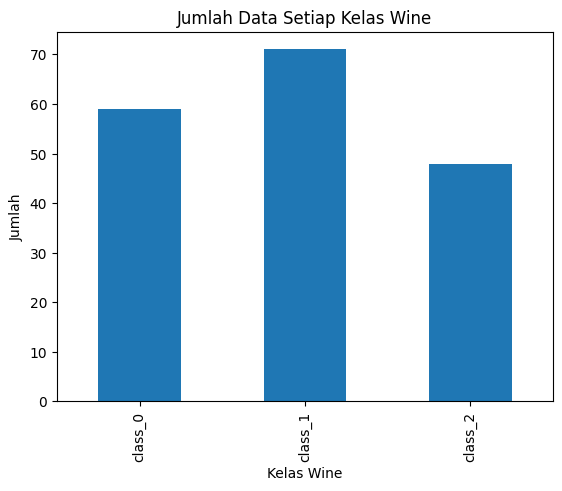

In [ ]:
df_wine["wine_class"].value_counts().sort_index().plot(kind="bar")

plt.title("Jumlah Data Setiap Kelas Wine")
plt.xlabel("Kelas Wine")
plt.ylabel("Jumlah")

plt.show()

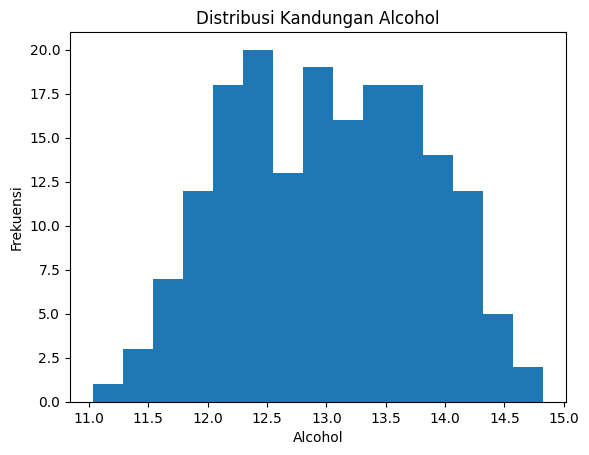

In [ ]:
plt.hist(df_wine["alcohol"], bins=15)

plt.title("Distribusi Kandungan Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frekuensi")

plt.show()

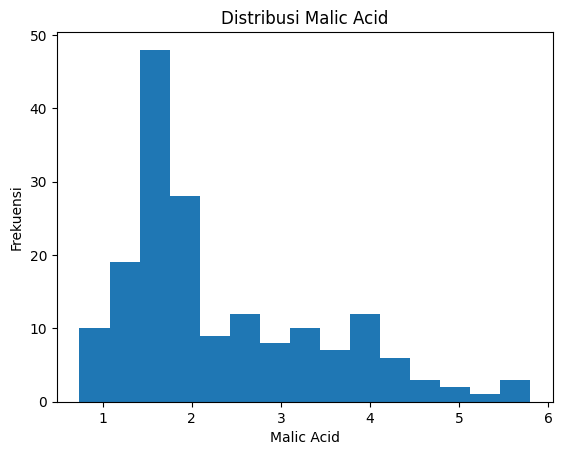

In [ ]:
plt.hist(df_wine["malic_acid"], bins=15)

plt.title("Distribusi Malic Acid")
plt.xlabel("Malic Acid")
plt.ylabel("Frekuensi")

plt.show()

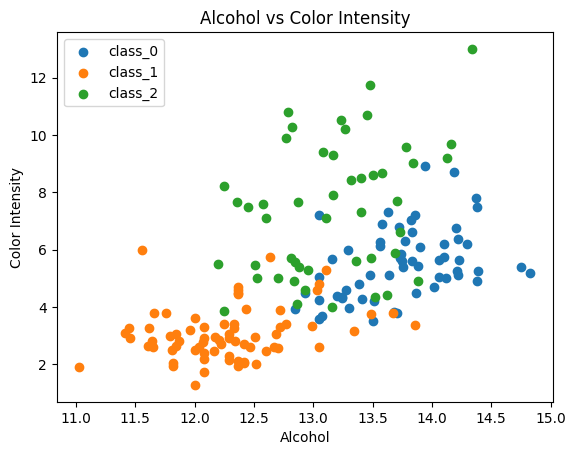

In [ ]:
for target, label in enumerate(wine.target_names):

    data = df_wine[df_wine["target"] == target]

    plt.scatter(
        data["alcohol"],
        data["color_intensity"],
        label=label
    )

plt.title("Alcohol vs Color Intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

plt.legend()

plt.show()

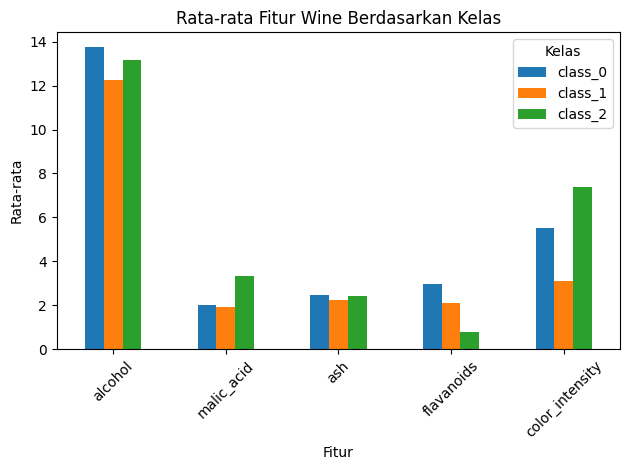

In [ ]:
selected_features = [
    "alcohol",
    "malic_acid",
    "ash",
    "flavanoids",
    "color_intensity"
]

df_wine.groupby("wine_class")[selected_features].mean().T.plot(
    kind="bar"
)

plt.title("Rata-rata Fitur Wine Berdasarkan Kelas")

plt.xlabel("Fitur")
plt.ylabel("Rata-rata")

plt.xticks(rotation=45)

plt.legend(title="Kelas")

plt.tight_layout()

plt.show()

In [ ]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
model_wine = LogisticRegression(max_iter=10000)

model_wine.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


In [ ]:
y_pred = model_wine.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)

Akurasi: 0.9629629629629629

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



# Kesimpulan

Dari tugas ini saya dapat memahami bahwa Machine Learning bekerja dengan mempelajari pola dari data.

Dataset dibagi menjadi data training dan testing agar kemampuan model dapat diuji menggunakan data baru. Hasil evaluasi tidak hanya dilihat dari akurasi, tetapi juga dari precision, recall, dan f1-score.

Pipeline Machine Learning yang dilakukan dalam tugas ini adalah:

Mengambil Data → Memahami Data → Visualisasi → Train/Test Split → Melatih Model → Prediksi → Evaluasi

Melalui tugas ini, saya menjadi lebih memahami konsep dasar supervised learning dan cara sebuah model melakukan klasifikasi berdasarkan data yang diberikan.